## Requirements for this assignment
* From scratch, code two linear regression models on the Boston Housing dataset
    - The first model should be the least square solution
    - The second model should be the Least Mean Square Algorithm
* Split the training data by 2/3 <span style="color:Green">Done</span>.
* Use different random initializations for the weights and the train test split(Do different random seeds) <span style="color:Green">Done</span>.
    - Calculate the variance of compiled results <span style="color:Yellow">Done for LS Solution</span>.
* Present the training and test errors <span style="color:Yellow">Partially done for LS Solution</span>.
* In th least square solution show:
    - the effect of different levels of regularizations to compute the inverse. <span style="color:Red">Need to add reg terms to LS solution</span>.
* When training with LMS:
    - Show the effect of different learning rates by plotting the learning curve. <span style="color:yellow">Learning Curve is plotted</span>.
    - Compare the accuracy of LMS with the analytics solution for the best initialization.

* Answer if a target variable is used as an input, what happens? 
    - Explain the result by visualizing the learned parameters of the model
* Answer if the bias term in the model improves the performance of this problem <span style="color:Red">Need to add Bias term to both solutions</span>.

# Data Loading

In [62]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.model_selection import train_test_split

In [63]:
# Read the file, assuming it is saved as "data.txt"
df = pd.read_csv("boston_housing_data.csv", header=None)
df.columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [64]:
# Split the data into training and test sets (MEDV is the target)
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.2, random_state=1,shuffle=False)

# Print the first few rows of the training data and the labels
print(X_train.head(), "\n")
print("Labels: ", "\n", y_train.head())

# convert to numpy arrays
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33   

Labels:  
 0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64


## Least square solution for regression

In [65]:
class least_squares_regressor():
    def __init__(self):
        self.weights = None
        
    def fit(self, X, y, C=1):
        n_samples, m_features = X.shape
        self.weights= np.linalg.inv( X.T @ X + C * np.identity(m_features)) @ X.T @ y # Ridge regularization term is there
        return self.weights
    
    def predict(self, X):
        # Predict the output using the learned weights
        return X @ self.weights + np.linalg.norm(self.weights)
    
    def mse(self, X, y):
        # Calculate the mean squared error
        return np.mean((self.predict(X) - y)**2)
    
    def get_weights(self):
        return self.weights

## Performance Analysis Without Regularizer

Train MSE variance:  169.50872345407527
Test MSE variance:  766.334371296822


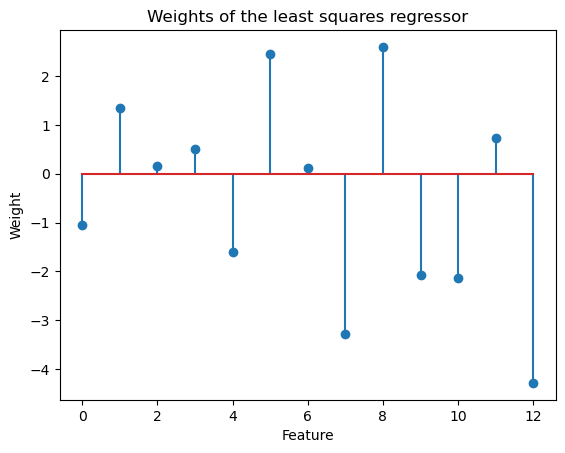

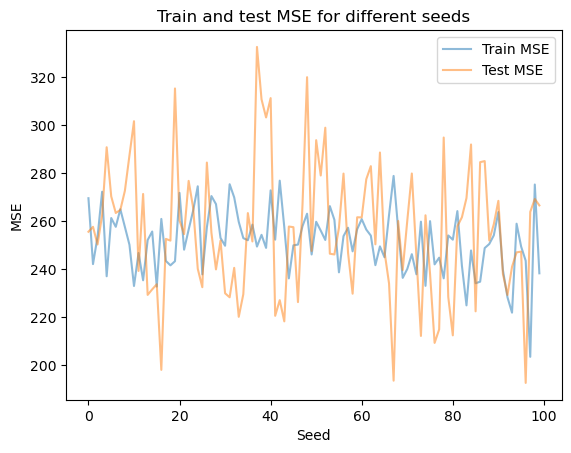

In [66]:
seeds = np.arange(100)
train_mse_history = []
test_mse_history = []
for seed in seeds:
    # Train the least squares regressor
    regressor = least_squares_regressor()

    # Train test split
    X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.3, random_state=seed,shuffle=True)
    
    # convert to numpy arrays
    X_train = X_train.to_numpy()
    X_test = X_test.to_numpy()
    y_train = y_train.to_numpy()
    y_test = y_test.to_numpy()
    
    # Scale the data
    X_train = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
    X_test = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
    
    regressor.fit(X_train, y_train,C=0.003)

    train_mse = regressor.mse(X_train, y_train)
    train_mse_history.append(train_mse)

    test_mse = regressor.mse(X_test, y_test)
    test_mse_history.append(test_mse)

# Calculate variances
train_mse_variance = np.var(train_mse_history)
test_mse_variance = np.var(test_mse_history)
print("Train MSE variance: ", train_mse_variance)
print("Test MSE variance: ", test_mse_variance)

# Stem plot of the weights
plt.stem(regressor.get_weights())
plt.xlabel("Feature")
plt.ylabel("Weight")
plt.title("Weights of the least squares regressor")
plt.show()

plt.plot(seeds, train_mse_history, label="Train MSE",alpha=0.5)
plt.plot(seeds, test_mse_history, label="Test MSE",alpha=0.5)
plt.xlabel("Seed")
plt.ylabel("MSE")
plt.title("Train and test MSE for different seeds")
plt.legend()
plt.show()

## Performance with Regularization

# LMS Algorithm

In [67]:
# Scale the data
X_train = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
X_test = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)

In [68]:
class LMSRegression:
    def __init__(self,learning_rate,epochs):
        # Hyperparameters
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.loss_history=[]
        
    def fit(self, X,d):
        # Initialize weights and biases
        n_samples, m_weights = X.shape
        self.weights=np.random.randn(m_weights)
        # Training loop - epochs
        for epoch in range(self.epochs):
                
            # Calculate the error
            e = d - X@self.weights
            # Calculate the gradient vector
            grad_vector = self.learning_rate*e@X
            
            # Update the weights
            self.weights = self.weights + grad_vector
            
            # Calculate mse
            mse = self.mse(X,d)
            self.loss_history.append(mse)
                
    def predict(self,X):
        return X @self.weights
    
    def mse(self,X,y):
        return np.mean((self.predict(X)-y)**2)
    
    def plot_loss(self):
        plt.plot(self.loss_history)
        plt.xlabel("Epoch")
        plt.ylabel("MSE")
        plt.title("Train MSE vs Epoch")
        plt.show()
    
# Test LMS Regression
lms = LMSRegression(learning_rate=0.1e-5, epochs=100_000)
lms.fit(X_train, y_train)
y_pred = lms.predict(X_test)

print("FINAL TRAIN MSE: ", lms.mse(X_train, y_train))
print("FINAL_TEST MSE: ", lms.mse(X_test, y_test))

FINAL TRAIN MSE:  518.3196349122037
FINAL_TEST MSE:  556.9141480118761


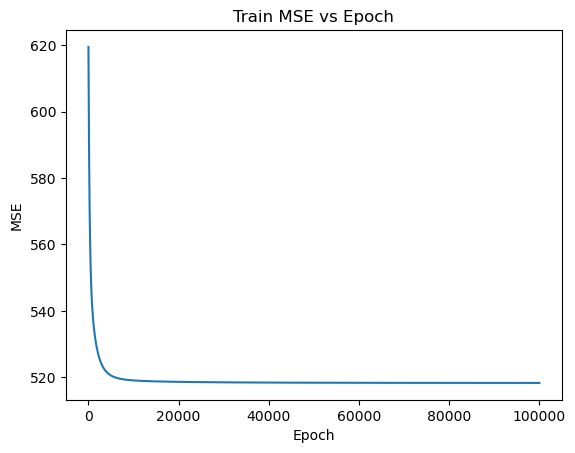

In [69]:
# Plot the loss
lms.plot_loss()

## Initialization test for LMS